In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [2]:
# Пути к данным
PATH = 'peper/'
TRAIN_PATH = PATH + 'homography_data.csv'

# Загрузка данных
train_df = pd.read_csv(TRAIN_PATH)
display(train_df.head())



,image_path,h11,h12,h13,h21,h22,h23,h31,h32
0,peper/input_images\1.png,1.550024,0.085322,-76.249814,-0.200061,2.200670,-118.436065,-0.000760,0.001391
1,peper/input_images\1frame_0000.png,1.756865,0.111463,-288.996300,0.079723,2.642253,-698.784706,0.000056,0.000388
2,peper/input_images\1frame_0001.jpg,1.782410,0.115527,-295.913089,0.046910,2.685599,-753.539157,0.000049,0.000381
3,peper/input_images\1frame_0002.jpg,1.702126,0.072652,-254.426312,0.032984,2.484775,-556.237677,0.000002,0.000310
4,peper/input_images\1frame_0003.jpg,1.784545,0.088949,-279.211813,0.046527,2.558977,-646.444046,0.000023,0.000314


In [3]:
# Преобразование данных
train_images = [cv2.imread(img_path) for img_path in train_df['image_path']]
train_labels = train_df.iloc[:, 1:].values  # Параметры гомографии



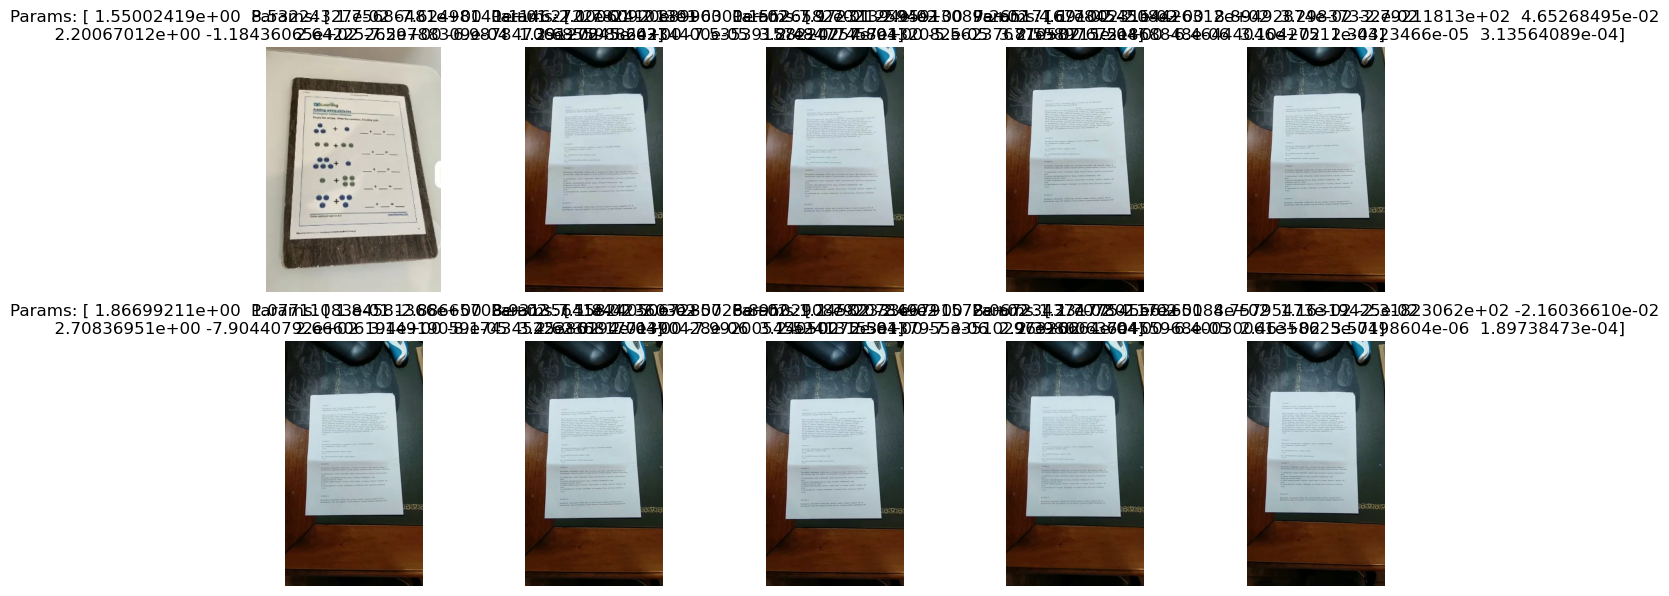

In [4]:
# Функция для отображения изображений
def display_images(images, labels, rows=2, cols=5):
    fig = plt.figure(figsize=(15, 7))
    for index in range(rows * cols):
        ax = fig.add_subplot(rows, cols, index + 1)
        ax.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
        ax.set_title(f"Params: {labels[index]}")
        ax.axis('off')
    plt.show()

display_images(train_images, train_labels)

In [5]:


# Разделение данных на обучающую и тестовую выборки
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=101
)


In [6]:
# Функция для добавления шума
def add_noise(image):
    # Гауссовский шум
    mean = 0
    var = 10
    sigma = var ** 0.5
    gaussian = np.random.normal(mean, sigma, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, gaussian)
    
    # Соль-и-перец
    s_vs_p = 0.5
    amount = 0.004
    out = np.copy(noisy_image)
    
    # Соль
    num_salt = np.ceil(amount * image.size * s_vs_p)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    out[coords[0], coords[1], :] = 255
    
    # Перец
    num_pepper = np.ceil(amount * image.size * (1.0 - s_vs_p))
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    out[coords[0], coords[1], :] = 0
    
    return out

In [7]:
# Функция для добавления лёгкого размытия
def add_blur(image):
    return cv2.GaussianBlur(image, (5, 5), 0)

In [8]:
# Функция для изменения яркости и контраста
def adjust_brightness_contrast(image, alpha=1.0, beta=10):
    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

In [9]:
# Класс для создания датасета
class CreateDataset(Dataset):
    def __init__(self, X, y, transform=None, augment=False):
        self.X = X
        self.y = y
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inp = self.X[idx].astype(np.float32)
        out = self.y[idx].astype(np.float32)

        if self.augment:
            # Применяем аугментации
            inp = add_noise(inp)
            inp = add_blur(inp)
            inp = adjust_brightness_contrast(inp)

        if self.transform:
            inp = self.transform(inp)

        return inp, out


In [10]:
# Преобразования для изображений (без изменения размера)
t = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [11]:


# Улучшенная архитектура модели
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(256 * 32 * 32, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 8)  # 8 параметров гомографии

    def forward(self, x):
        x = self.relu(self.bn1(self.pool(self.conv1(x))))
        x = self.relu(self.bn2(self.pool(self.conv2(x))))
        x = self.relu(self.bn3(self.pool(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [12]:

# Обучение модели
EPOCHS = 20
net = Net()
criterion = nn.MSELoss()  # Среднеквадратичная ошибка для регрессии
optimizer = AdamW(net.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)  # Learning Rate Scheduler

train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    for data in train_loader:
        X_train, y_train = data
        optimizer.zero_grad()
        y_pred = net(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        running_loss += train_loss.item()
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()

    # Тестирование на валидационной выборке
    net.eval()
    test_loss = 0.0
    with torch.no_grad():
        for data in test_loader:
            X_test, y_test = data
            output = net(X_test)
            test_loss += criterion(output, y_test).item()
    test_losses.append(test_loss / len(test_loader))

    print(f"Epoch: {epoch + 1}, Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

# Визуализация потерь
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()



NameError: name 'train_loader' is not defined

In [ ]:
# Функция для тестирования на одном изображении
def test_single_image(image_path, model, output_path, scaler):
    # Преобразования для изображения
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Загрузка и предобработка изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: Не удалось загрузить изображение {image_path}.")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_tensor = transform(image_rgb).unsqueeze(0)  # Добавляем batch dimension

    # Предсказываем параметры гомографии
    with torch.no_grad():
        predicted_params = model(image_tensor)

    # Обратная нормализация параметров
    predicted_params = scaler.inverse_transform(predicted_params.numpy())

    # Преобразуем параметры в матрицу гомографии
    M = np.append(predicted_params.flatten(), 1.0).reshape(3, 3)

    # Выравниваем изображение
    height, width = image.shape[:2]
    aligned_image = cv2.warpPerspective(image, M, (width, height))

    # Сохраняем результат
    cv2.imwrite(output_path, aligned_image)
    print(f"Выровненное изображение сохранено как {output_path}.")

    # Показываем результат
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Исходное изображение")
    ax[0].axis('off')

    ax[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Выровненное изображение")
    ax[1].axis('off')

    plt.show()

# Пример использования
test_image_path = "peper/extracted_frames/4frame_0103.jpg"  # Путь к тестовому изображению
output_image_path = "peper/extracted_frames/aligned_test_image.png"  # Путь для сохранения результата
test_single_image(test_image_path, net, output_image_path, scaler)